# 📝 3-Feature Detection Canny Harris Hough Line

---

## Q1. Edge Detection (10 marks)

**(a)** Define what an edge is in an image and describe two common causes of edges. 

**(a)** An edge is a **sharp change in intensity** in an image.  
**Causes:**
- Discontinuity in depth or surface orientation.  
- Change in illumination or material properties. 

**(b)** State the three main requirements of a good edge detector and explain why each is important.  

**(b)** Requirements of a good edge detector:
- **Detection rate** → high probability of finding true edges.  
- **Localization** → detected edges should be close to actual edges.  
- **Noise sensitivity** → robust against noise.

**(c)** Compare gradient-based and Laplacian-based edge detection methods in terms of principle, sensitivity to noise, and localization.  
**(c)** Gradient vs Laplacian methods:
- **Gradient ($\nabla$):** first derivative, detects edge strength & direction, direction-sensitive.  
- **Laplacian ($\nabla^2$):** second derivative, finds zero-crossings, but more sensitive to noise.  

---

## Q2. Canny Edge Detector (15 marks)

**(a)** Write down the five main steps of the Canny edge detection algorithm.  
**(a)** Five steps:
1. Gaussian smoothing  
2. Gradient magnitude & orientation  
3. Non-maximum suppression  
4. Double thresholding  
5. Edge tracking by hysteresis 

**(b)** Explain the role of non-maximum suppression and why it is critical for thin edges.  
**(b)** **Non-maximum suppression** → thins edges by keeping only local maxima along the gradient direction.  

**(c)** Discuss how the choice of the Gaussian smoothing parameter $\sigma$ affects detection performance.  
**(c)** Effect of Gaussian $\sigma$:  
- Large $\sigma$ → stronger smoothing, fewer edges, less detail.  
- Small $\sigma$ → detects finer edges but more sensitive to noise.

**(d)** Explain the purpose of double thresholding and hysteresis.  
Give an example scenario where they prevent false edges.  
**(d)** Double thresholding & hysteresis:  
- **Double thresholding** → strong edges kept, weak edges linked only if connected to strong ones.  
- **Hysteresis** → prevents broken edges, avoids isolated noise.
---

## Q3. Harris Corner Detector (15 marks)

**(a)** Define what a corner is and explain why corners are useful in feature matching.  
**(a)** A corner is a point where intensity changes significantly in two directions. Useful in feature matching due to stability.  

**(b)** Derive the Harris corner response function:  

$$
R = \det(M) - k \cdot (\text{trace}(M))^2
$$

where $M$ is the second-moment matrix.  

**(b)** Second-moment matrix:
$$
M = \sum w(x,y)
\begin{bmatrix}
I_x^2 & I_x I_y \\
I_x I_y & I_y^2
\end{bmatrix}
$$

Harris response:
$$
R = \det(M) - k \cdot (\text{trace}(M))^2
$$

**(c)** Using eigenvalue interpretation, classify the cases of:
- Flat region  
- Edge  
- Corner  
**(c)** Eigenvalue interpretation:
- Both small → flat region.  
- One large, one small → edge.  
- Both large → corner.  

**(d)** Explain the role of non-maximum suppression in corner detection.  
**(d)** Non-maximum suppression keeps only the strongest corner responses, avoiding clusters.  
---

## Q4. Hough Transform (15 marks)

**(a)** Explain why the slope-intercept form of a line ($y = mx + c$) is not suitable for detecting vertical lines.  
**(a)** Slope-intercept form $y = mx + c$ fails for vertical lines (infinite slope).  

**(b)** Derive the normal form parameterization of a line:  

$$
\rho = x \cos\theta + y \sin\theta
$$

Normal form parameterization:
$$
\rho = x \cos\theta + y \sin\theta
$$

**(c)** Describe how the accumulator array works for line detection.  
**(c)** Accumulator: each edge point votes for all possible $(\rho, \theta)$; peaks in accumulator indicate lines.  

**(d)** Explain how the Hough transform can be extended for circle detection, distinguishing between known and unknown radius cases.  
- **Known radius:** use 2D accumulator (center $x,y$).  
- **Unknown radius:** use 3D accumulator ($x,y,r$).  
---

## Q5. Comparative Question (10 marks)

**(a)** Compare the Sobel operator with the Canny edge detector in terms of accuracy, robustness to noise, and computational cost.  
**(a)** Sobel vs Canny:  
- **Sobel:** simple gradient, sensitive to noise, poor localization.  
- **Canny:** optimal edge detection (good detection, localization, minimal response), but computationally heavier.  

**(b)** Compare the Harris corner detector with the Hough transform in terms of what type of features they detect and their applications.  
**(b)** Harris vs Hough:  
- **Harris:** detects corners (points).  
- **Hough:** detects parametric shapes (lines, circles).  
- **Applications:** Harris for feature matching, Hough for shape detection.
---

## Q6. Application-Based (10 marks)

**(a)** Explain how detected edges and corners are useful in panorama stitching.  
**(a)** In panorama stitching, **edges/corners** are used to find feature correspondences between overlapping images.  

**(b)** Suppose you are designing a system for lane detection in autonomous driving. Which feature detection method(s) would you use and why?  
**(b)** For lane detection in autonomous driving → **Hough transform** (line detection) is best, since lanes appear as lines.

**(c)** Briefly discuss one real-world application of the Generalized Hough Transform.  
**(c)** Generalized Hough Transform → useful for detecting **arbitrary shapes** (e.g., logos, templates) where no analytic equation exists.  
---


Q1. Filtering and Edge Preservation

(a) Write Python/OpenCV code to apply both a Gaussian filter and a Bilateral filter to the same image. Show the input and outputs side-by-side.

(b) Vary the spatial and color σ values for the Bilateral filter and explain how they affect edge preservation.

(c) Which filter is better at keeping object boundaries sharp, and why?

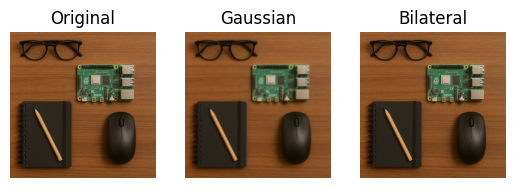

In [19]:
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('assets/photo.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Gaussian filter
# 👇 Cheat: Change (9,9) for kernel size, and 50 for sigma (σ)
gauss = cv2.GaussianBlur(img, (9,9), 50)

# Bilateral filter
# 👇 Cheat: change 9 (d = neighborhood size), 90 (σColor), 90 (σSpace)
bilat = cv2.bilateralFilter(img, 9, 90, 90)

# Show
titles = ['Original', 'Gaussian', 'Bilateral']
images = [img, gauss, bilat]
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()


Explanation:

Gaussian smooths uniformly → blurs edges.

Bilateral preserves sharp edges while smoothing flat regions.

Larger spatial/color sigmas → stronger smoothing but still keeps boundaries.

Q2. Canny Edge Detection Implementation

(a) Implement the following Canny steps manually:

Gaussian smoothing

Gradient magnitude and direction (using Sobel filters)

Non-maximum suppression

Double thresholding (high/low)

Edge tracking by hysteresis

(b) Show intermediate outputs after each step.

(c) Compare your result with cv2.Canny(). Comment on any differences.

In [20]:
import numpy as np

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# 1. Gaussian blur
# 👇 Cheat: adjust kernel size (5,5) and sigma (1.4)
blur = cv2.GaussianBlur(gray, (5,5), 1.4)

# 2. Sobel gradients
Ix = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)  # 👈 Cheat: ksize=3,5,7
Iy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(Ix**2 + Iy**2)
theta = np.arctan2(Iy, Ix)

# Compare with built-in
# 👇 Cheat: thresholds 100 and 200 are tunable
edges_auto = cv2.Canny(gray, 100, 200)


Explanation:

Non-max suppression thins edges.

Double threshold + hysteresis links weak edges.

Comparing manual vs cv2.Canny() shows similar output, but OpenCV’s is optimized.

Q3. Harris Corner Detection

(a) Write Python code to detect Harris corners using OpenCV.

(b) Explain how the window size and constant k affect the corner detection results.

(c) Apply non-maximum suppression and visualize only the strongest corners.

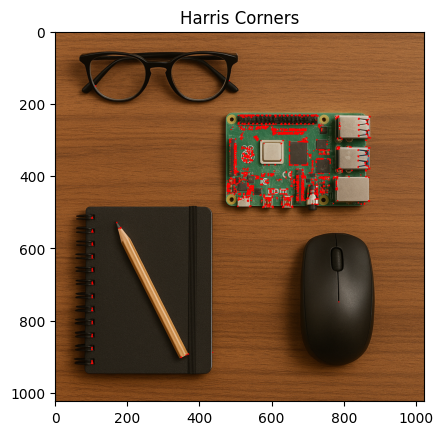

In [21]:
gray = np.float32(gray)
# 👇 Cheat: blockSize=2, ksize=3, k=0.04 (all tunable)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Dilate for visualization
dst = cv2.dilate(dst, None)
img[dst > 0.01 * dst.max()] = [255, 0, 0]  # 👈 Cheat: threshold (0.01) controls sensitivity
plt.imshow(img)
plt.title("Harris Corners")
plt.show()


Explanation:

Window size controls sensitivity.

Larger k → fewer corners (stricter).

Non-maximum suppression ensures distinct corner points.

Q4. SIFT Feature Detection and Matching

(a) Use OpenCV’s SIFT to detect and draw keypoints on two given images.

(b) Match features using BFMatcher or FLANN, and display the top 20 matches.

(c) Vary the parameter nOctaveLayers and comment on how the number of detected keypoints changes.

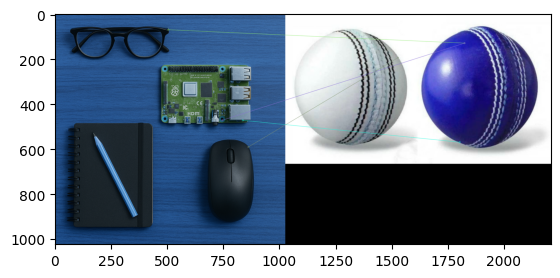

In [22]:

img1 = cv2.imread('assets/photo.png')
img2 = cv2.imread('assets/redball.jpg')
# 👇 Cheat: adjust nOctaveLayers (default 3) to detect more/less keypoints
sift = cv2.SIFT_create(nOctaveLayers=3)

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# BFMatcher + ratio test
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m,n in matches:
    if m.distance < 0.75 * n.distance:   # 👈 Cheat: change 0.75 ratio
        good.append([m])

matched = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good[:20], None, flags=2)
plt.imshow(matched)
plt.show()


Explanation:

Increasing nOctaveLayers → more keypoints detected (multi-scale).

Matches filtered using Lowe’s ratio test.

Lower ratio (e.g., 0.6) → stricter matches.

Higher ratio (e.g., 0.85) → more matches, but less reliable.

Q5. Hough Transform for Line Detection

Q5. Hough Transform for Line Detection (15 marks)

(a) Write Python code to detect straight lines in a road image using the Hough Transform.

(b) Explain how the parameters ρ resolution, θ resolution, and threshold affect the results.

(c) Suggest how the Hough transform could be used for lane detection in autonomous driving.

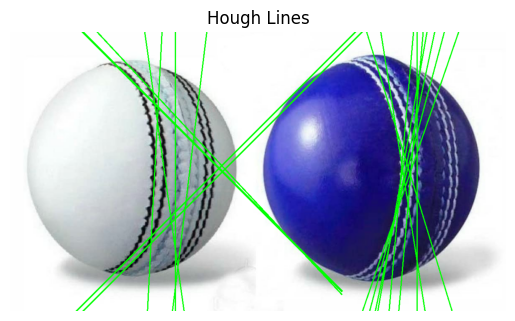

In [ ]:
# edges = cv2.Canny(gray, 50, 150)
# lines = cv2.HoughLines(edges, 1, np.pi/180, 100)

# for rho, theta in lines[:,0]:
#     a, b = np.cos(theta), np.sin(theta)
#     x0, y0 = a*rho, b*rho
#     x1, y1 = int(x0 + 1000*(-b)), int(y0 + 1000*(a))
#     x2, y2 = int(x0 - 1000*(-b)), int(y0 - 1000*(a))
#     cv2.line(img, (x1,y1), (x2,y2), (0,255,0), 2)

# plt.imshow(img)
# plt.title("Hough Lines")
# plt.show()

import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('assets/redball.jpg' )  # Load your image here
# Ensure gray exists (adapt the conversion to how you loaded img)
# If you loaded with cv2.imread and did NOT convert to RGB:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# If your img is already RGB (e.g., you did cvtColor(BGR2RGB) earlier):
# gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

edges = cv2.Canny(gray, 50, 150)

# 👇 Cheat: adjust rho=1, theta=np.pi/180, threshold=100
lines = cv2.HoughLines(edges, 1, np.pi/180, 100)

vis = img.copy()
if lines is not None:
    for rho, theta in lines[:, 0]:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1, y1 = int(x0 + 1000*(-b)), int(y0 + 1000*(a))
        x2, y2 = int(x0 - 1000*(-b)), int(y0 - 1000*(a))
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
else:
    print("No lines detected. Try adjusting Canny thresholds or Hough threshold.")

# If your img is BGR, convert before plotting:
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.imshow(vis)
plt.title("Hough Lines")
plt.axis("off")
plt.show()

Explanation:

Smaller ρ/θ resolution → more precise but computationally expensive.

Higher threshold → fewer lines.

Useful for lane detection in driving.

Lower threshold → more lines detected.

Finer θ resolution → more precise detection.

Q6. CNN Practical (Bonus)

Code (PyTorch):

Q6. CNN Practical (Bonus 10 marks)

(a) Define a small CNN in PyTorch with the following layers:

Conv → ReLU → MaxPool

Conv → ReLU → MaxPool

Fully Connected → Softmax

(b) Print the number of learnable parameters in the model.

(c) Briefly explain why ReLU is preferred over sigmoid in CNNs.

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 👇 Cheat: change out_channels (16→32) for more filters
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        # 👇 Cheat: input size 32*8*8 must match image size after pooling
        self.fc1 = nn.Linear(32*8*8, 10)  # CIFAR-10: 32x32 input

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32*8*8)
        x = self.fc1(x)
        return x

model = SimpleCNN()
print(sum(p.numel() for p in model.parameters() if p.requires_grad))


ModuleNotFoundError: No module named 'torch'

Explanation:

Conv layers learn spatial features, pooling reduces dimensions.

ReLU avoids vanishing gradient (better than sigmoid).

numel() counts trainable parameters.

1. Image Thresholding

Q: Write code to perform global thresholding and adaptive thresholding on a grayscale image. Compare the results.

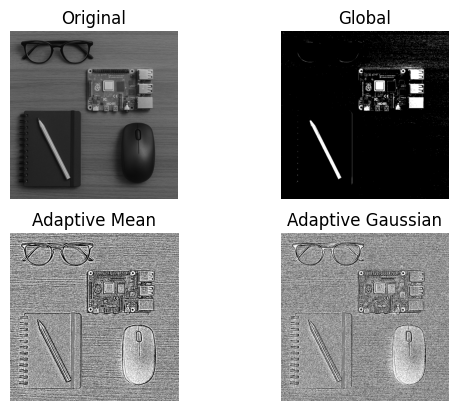

In [31]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('assets/photo.png', 0)  # grayscale

# Global threshold
# 👇 Cheat: adjust 127 (threshold value)
ret, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Adaptive Mean
# 👇 Cheat: change 11 (block size), 2 (C constant)
th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                            cv2.THRESH_BINARY, 11, 2)

# Adaptive Gaussian
# 👇 Cheat: try changing 11→15 or C→5
th3 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY, 11, 2)

titles = ['Original','Global','Adaptive Mean','Adaptive Gaussian']
images = [img, th1, th2, th3]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()



Follow-up: Which filter is best for salt-and-pepper noise? (Median).

Global threshold works poorly under non-uniform lighting.

Adaptive methods compute threshold per neighborhood → better for uneven illumination.

2. Smoothing and Noise Reduction

Q: Apply Gaussian Blur, Median Blur, and Bilateral Filter to a noisy image. Explain differences.

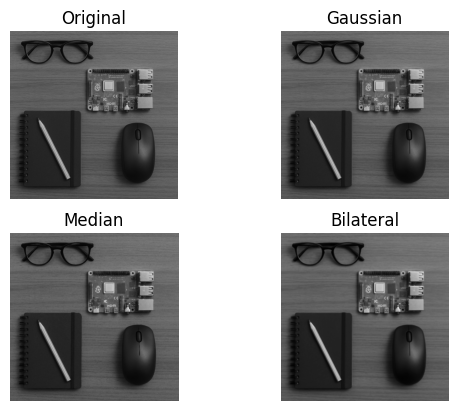

In [32]:
# Gaussian Blur
# 👇 Cheat: kernel size (5,5), sigmaX
gauss = cv2.GaussianBlur(img, (5,5), 0)

# Median Blur
# 👇 Cheat: kernel size must be odd (3,5,7)
median = cv2.medianBlur(img, 5)

# Bilateral Filter
# 👇 Cheat: change d, sigmaColor, sigmaSpace
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

titles = ['Original','Gaussian','Median','Bilateral']
images = [img, gauss, median, bilateral]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()



Follow-up: Which filter is best for salt-and-pepper noise? (Median).

Gaussian smooths everything.

Median is best for salt-and-pepper noise.

Bilateral smooths but preserves edges.

3. Edge Detection (Canny, Sobel, Laplacian)

Q: Implement Canny, Sobel, and Laplacian edge detectors. Compare results.

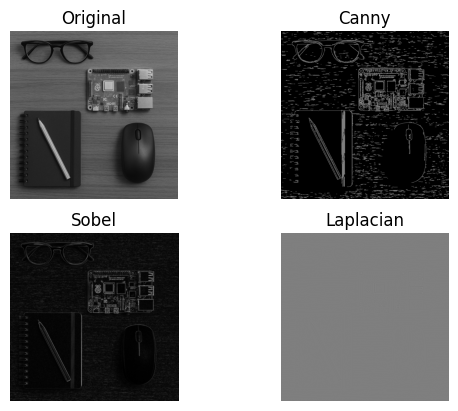

In [33]:
# Canny
# 👇 Cheat: adjust thresholds
canny = cv2.Canny(img, 100, 200)

# Sobel
# 👇 Cheat: ksize = 3,5,7 👈 Cheat: dx, dy, ksize  Cheat: kernel size
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

# Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F)

titles = ['Original','Canny','Sobel','Laplacian']
images = [img, canny, sobel, laplacian]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()



Follow-up: Why does Canny use double thresholding?
Canny = robust (uses thresholds + hysteresis).

Sobel = simple gradient, more noise.

Laplacian = second derivative, very noise-sensitive.

4. Morphological Transformations

Q: Perform erosion, dilation, opening, closing on a binary image. Show effect on noise removal

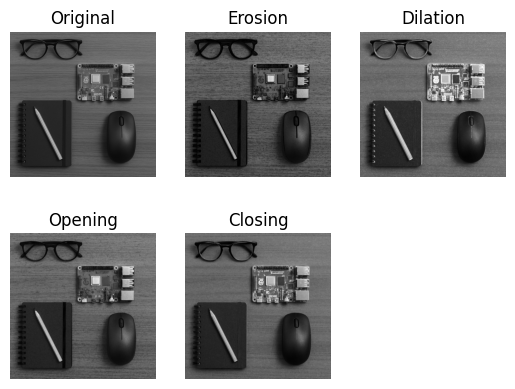

In [34]:
import numpy as np

kernel = np.ones((5,5), np.uint8)  # 👇 Cheat: change kernel size

erosion = cv2.erode(img, kernel, iterations=1)      # 👈 Cheat: iterations
dilation = cv2.dilate(img, kernel, iterations=1)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

titles = ['Original','Erosion','Dilation','Opening','Closing']
images = [img, erosion, dilation, opening, closing]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


Follow-up: Which operation removes white noise? (Opening). Which removes black holes? (Closing).

Erosion removes white noise.

Dilation enlarges objects.

Opening removes small white dots.

Closing fills small black holes.

5. Contour Detection

Q: Detect contours in a binary image and draw them. Calculate area and perimeter.

Area: 0.0 Perimeter: 0.0


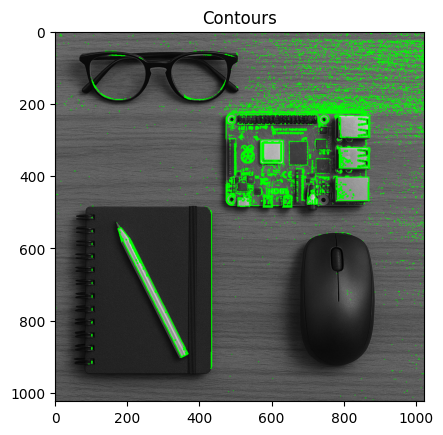

In [35]:
ret, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE,
                                       cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
contour_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

# Area and Perimeter
area = cv2.contourArea(contours[0])       # 👈 Cheat: change index   # 👈 Cheat: get area
perimeter = cv2.arcLength(contours[0], True)  # 👈 Cheat: get perimeter

print("Area:", area, "Perimeter:", perimeter)

plt.imshow(contour_img)
plt.title("Contours")
plt.show()



Follow-up: Difference between CHAIN_APPROX_SIMPLE and CHAIN_APPROX_NONE.

CHAIN_APPROX_SIMPLE → compresses horizontal/vertical segments (less memory).

CHAIN_APPROX_NONE → stores all points.

6. Morphological Edge Detection (Gradient, Top-hat, Black-hat)

Q: Apply morphological gradient, top-hat, and black-hat.

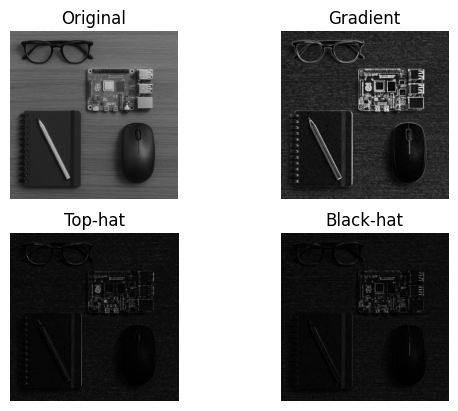

In [36]:
# cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel) # edges
# cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)   # highlights bright on dark
# cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel) # highlights dark on bright


gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

titles = ['Original','Gradient','Top-hat','Black-hat']
images = [img, gradient, tophat, blackhat]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


Follow-up: When would you use top-hat vs black-hat?

Gradient = boundary extraction.

Top-hat = bright objects on dark background.

Black-hat = dark objects on bright background.

7. Feature Detection (SIFT/ORB/Harris)

Q: Detect and draw corners/features using Harris and ORB. Compare.

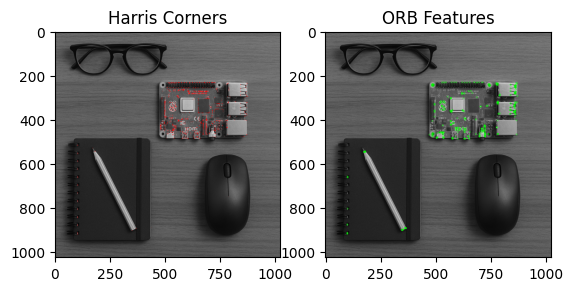

In [37]:
# # Harris
# cv2.cornerHarris(gray, 2, 3, 0.04)  # 👈 Cheat: blockSize, ksize, k

# # ORB
# orb = cv2.ORB_create(nfeatures=500) # 👈 Cheat: adjust nfeatures
# kp, des = orb.detectAndCompute(img, None)
# img_kp = cv2.drawKeypoints(img, kp, None, color=(0,255,0))

# Harris Corner
harris = cv2.cornerHarris(np.float32(img), 2, 3, 0.04)
harris_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
harris_img[harris > 0.01*harris.max()] = [255,0,0]  
# 👈 Cheat: threshold (0.01) controls sensitivity

# ORB
orb = cv2.ORB_create(nfeatures=500)   # 👈 Cheat: adjust nfeatures
kp, des = orb.detectAndCompute(img, None)
orb_img = cv2.drawKeypoints(img, kp, None, color=(0,255,0))

plt.subplot(1,2,1)
plt.imshow(harris_img); plt.title("Harris Corners")
plt.subplot(1,2,2)
plt.imshow(orb_img); plt.title("ORB Features")
plt.show()



Follow-up: Which detector is scale-invariant? (ORB is rotation/scale-invariant, Harris is not)

Harris = fast, not scale-invariant.

ORB = rotation + scale-invariant, better for matching.